# Tuning Exploration Parameters

## 📚 Learning Objectives

By completing this notebook, you will:
- Tune exploration parameters (epsilon, temperature, etc.)
- Understand parameter impact on performance
- Find optimal exploration settings
- Apply parameter tuning strategies

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 5, lesson 01 "01. Grid Search and Random Search" — the same sweep-and-compare procedure, except each configuration costs a full training run and the score you compare is a noisy average over episodes.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 4**:
- Tuning exploration parameters

---

## Introduction

Tuning exploration parameters is crucial for balancing exploration and exploitation effectivel

## Lesson Brief

This lesson shows that exploration is not only about choosing a strategy, but also about tuning its parameters well.

Students will see how choices such as epsilon size or decay schedule affect learning outcomes.

Why this matters: an algorithm can fail not because the idea is wrong, but because its exploration settings are poor.

This lesson builds practical instinct for parameter tuning.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: how Yahoo chose its exploration parameters without deploying them

Every earlier lesson in this unit ended with a caveat: one run cannot rank close strategies. This
lesson is about what industry actually does instead.

When Li, Chu, Langford and Schapire's contextual bandit went onto the Yahoo! front page (WWW 2010),
the parameter choices were not made by deploying candidates and watching. They were made against
**over 33 million logged events** using an offline *replay* estimator, proved unbiased in a companion
paper (Li, Chu, Langford and Wang, "Unbiased Offline Evaluation of Contextual-bandit-based News
Article Recommendation Algorithms", WSDM 2011). The trick is simple and worth remembering: because
the logging policy chose articles at random from the pool, you can score any new policy on the
subset of logged events where it would have chosen the same article — and that subset is an unbiased
sample. The authors then checked the offline estimates against live online buckets and showed they
agreed.

So the deployed system's parameters were selected the way this notebook selects ε: by averaging over
a large number of independent trials, not by watching one.

**What goes wrong without this.** You tune on a single run, ship the parameter, and the improvement
evaporates. The table below measures precisely how often that would happen — and the answer is
uncomfortable.


## Recommended YouTube Video

To reinforce this lesson, watch **ritvikmath - "Best Multi-Armed Bandit Strategy? (feat: UCB Method)"**:
[Watch on YouTube](https://www.youtube.com/watch?v=FgmMK6RPU1c)

Why this pick:
- concrete parameter-sensitive examples.
- Helps students see how exploration settings change learning behavior over time.
- Good companion when interpreting tuning experiments rather than only running them.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nTuning Exploration Parameters")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nKey Exploration Parameters:")
# Show text or numbers in the cell output area under the code.
print("  - Epsilon (ε): Exploration rate for epsilon-greedy")
# Show text or numbers in the cell output area under the code.
print("  - Temperature (τ): For Boltzmann exploration")
# Show text or numbers in the cell output area under the code.
print("  - Confidence parameter (c): For UCB")
# Show text or numbers in the cell output area under the code.
print("  - Decay rate: For epsilon decay schedules")

# Show text or numbers in the cell output area under the code.
print("\nTuning Strategies:")
# Show text or numbers in the cell output area under the code.
print("  1. Grid search over parameter ranges")
# Show text or numbers in the cell output area under the code.
print("  2. Adaptive schedules (decay over time)")
# Show text or numbers in the cell output area under the code.
print("  3. Context-dependent parameters")
# Show text or numbers in the cell output area under the code.
print("  4. Performance-based tuning")

# Show text or numbers in the cell output area under the code.
print("\n✅ Parameter tuning concepts covered!")


✅ Libraries imported!

Tuning Exploration Parameters

Key Exploration Parameters:
  - Epsilon (ε): Exploration rate for epsilon-greedy
  - Temperature (τ): For Boltzmann exploration
  - Confidence parameter (c): For UCB
  - Decay rate: For epsilon decay schedules

Tuning Strategies:
  1. Grid search over parameter ranges
  2. Adaptive schedules (decay over time)
  3. Context-dependent parameters
  4. Performance-based tuning

✅ Parameter tuning concepts covered!


## 🌍 Worked Example — Tuning Epsilon in A/B Testing

**Industry context:**
- Product teams often keep the bandit setup fixed but tune exploration strength
- A weak epsilon can lock onto a bad option too early
- A very high epsilon can waste traffic on poor variants for too long

We run the same A/B test with several **epsilon values** so students can see how parameter tuning changes performance even when the strategy stays the same.

### Step Guide

**What this cell does:** Tunes ε **properly**: every ε value is run **50 times with different seeds**, and the comparison uses the *mean* total reward (± standard deviation) — because a single noisy run cannot rank exploration parameters.

**How to read it (weak Python OK):** `run_epsilon_greedy` is one simulation; the double loop repeats it 50× per ε. The table of means is the result; the "single-run trap" lines show why averaging was necessary.

**What to expect in the output:** A mean ± std table with the best ε computed from the means, a demonstration of how much single runs disagree, and a two-panel figure (average curves + mean totals with error bars).

**If you feel lost:** Compare the *spread* column with the *differences between rows* — when spread is as large as the differences, one run alone proves nothing.

Total reward per epsilon (50 runs of 2000 rounds each):
   ε    |  mean ± std   |  min … max across runs
  0.01 |   489.0 ± 120.3 |   292 …   704
  0.05 |   599.6 ±  76.2 |   314 …   697
   0.1 |   623.7 ±  50.1 |   475 …   691
   0.3 |   610.8 ±  35.7 |   508 …   673

Best epsilon by MEAN total reward: ε=0.1

The single-run trap: judging by one run alone, 27 of 50 runs
would have crowned a DIFFERENT epsilon than the 50-run average does.
That is why the earlier lessons' single-seed bandit plots can only illustrate
behaviour — ranking parameters requires averaging over many runs.


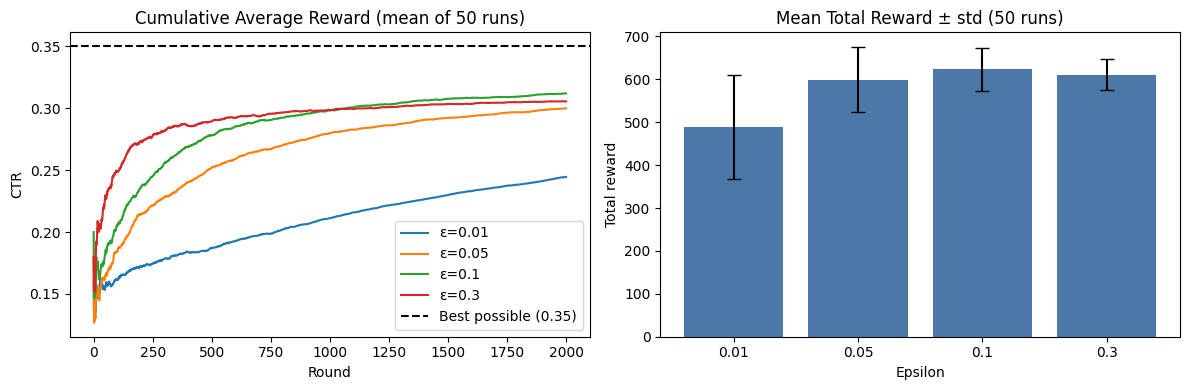

In [2]:
# Worked example: tune epsilon PROPERLY — many runs per value, conclusions from means.
# A single run per epsilon is a lottery ticket; averaging over seeds is what makes
# a tuning table trustworthy. We also SHOW the single-run trap explicitly below.

import numpy as np, matplotlib.pyplot as plt

# Hidden truth of the A/B test: 5 variants, variant 2 is best (35% CTR).
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]
N_ARMS = len(TRUE_RATES)
N_ROUNDS = 2000
EPSILONS = [0.01, 0.05, 0.10, 0.30]
N_RUNS = 50                      # independent simulations per epsilon value
BEST_RATE = max(TRUE_RATES)


def run_epsilon_greedy(eps, seed):
    """One full epsilon-greedy simulation; returns the per-round reward array."""
    rng = np.random.default_rng(seed)
    counts, totals = np.zeros(N_ARMS), np.zeros(N_ARMS)
    rewards = []
    for _ in range(N_ROUNDS):
        # Explore uniformly with probability eps, otherwise exploit the running means.
        if rng.random() < eps:
            arm = rng.integers(N_ARMS)
        else:
            arm = int(np.argmax(totals / (counts + 1e-9)))
        reward = 1 if rng.random() < TRUE_RATES[arm] else 0
        counts[arm] += 1
        totals[arm] += reward
        rewards.append(reward)
    return np.array(rewards)


# ── The experiment: N_RUNS independent simulations for every epsilon ─────────
results = {}
for eps in EPSILONS:
    # Different seed per run; the same 50 seeds are reused for every epsilon.
    run_matrix = np.stack([run_epsilon_greedy(eps, seed=1000 + k) for k in range(N_RUNS)])
    per_run_totals = run_matrix.sum(axis=1)
    results[eps] = {
        "mean_curve": run_matrix.cumsum(axis=1).mean(axis=0)
                       / np.arange(1, N_ROUNDS + 1),   # average cumulative CTR
        "totals": per_run_totals,                        # 50 total rewards
        "mean": per_run_totals.mean(),
        "std": per_run_totals.std(),
    }

# ── Report means, spread, and the best epsilon BY THE MEANS ──────────────────
print(f"Total reward per epsilon ({N_RUNS} runs of {N_ROUNDS} rounds each):")
print("   ε    |  mean ± std   |  min … max across runs")
for eps in EPSILONS:
    r = results[eps]
    print(f"  {eps:>4} |  {r['mean']:6.1f} ± {r['std']:5.1f} | {r['totals'].min():5.0f} … {r['totals'].max():5.0f}")

best_eps = max(results, key=lambda e: results[e]["mean"])
print(f"\nBest epsilon by MEAN total reward: ε={best_eps}")

# ── The single-run trap, demonstrated with this very data ────────────────────
# How often would looking at ONE run (same seed index for each ε) have picked
# a different winner than the 50-run average did?
single_run_winners = [max(EPSILONS, key=lambda e: results[e]["totals"][k]) for k in range(N_RUNS)]
disagree = sum(w != best_eps for w in single_run_winners)
print(f"\nThe single-run trap: judging by one run alone, {disagree} of {N_RUNS} runs")
print(f"would have crowned a DIFFERENT epsilon than the {N_RUNS}-run average does.")
print("That is why the earlier lessons' single-seed bandit plots can only illustrate")
print("behaviour — ranking parameters requires averaging over many runs.")

# ── Plots: averaged learning curves + mean totals with error bars ────────────
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for eps in EPSILONS:
    plt.plot(results[eps]["mean_curve"], label=f"ε={eps}")
plt.axhline(BEST_RATE, color="k", linestyle="--", label=f"Best possible ({BEST_RATE})")
plt.title(f"Cumulative Average Reward (mean of {N_RUNS} runs)")
plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend()

plt.subplot(1, 2, 2)
labels = [str(e) for e in EPSILONS]
means = [results[e]["mean"] for e in EPSILONS]
stds = [results[e]["std"] for e in EPSILONS]
plt.bar(labels, means, yerr=stds, capsize=5, color="#4C78A8")
plt.title(f"Mean Total Reward ± std ({N_RUNS} runs)")
plt.xlabel("Epsilon"); plt.ylabel("Total reward")
plt.tight_layout(); plt.show()


### 👁️ Read the figure

- **Left, the averaged learning curves** — each line is the mean of **50** runs, not one run,
  which is why they are smooth. The dashed ceiling is 0.35.
- **The curves cross, and the crossing is the point.** Red (ε = 0.3) climbs fastest and is
  ahead for the first ~1,000 rounds; green (ε = 0.1) overtakes it and ends highest. Blue
  (ε = 0.01) is still climbing at round 2,000 — it has not finished learning, it has barely
  started. **A shorter campaign would have picked a different ε than a longer one.**
- **Right, mean total reward with ±1 standard deviation.** Read the whiskers, not the bar
  tops: ε = 0.01's bar is lowest *and* its whisker is by far the longest (±120 on a mean of
  489). The three bars for ε = 0.05, 0.1 and 0.3 have overlapping whiskers.
- **The printed table says the rest:** judged one run at a time, **27 of the 50 runs would have
  crowned a different ε** than the 50-run average does.

**What it proves:** the tuned value of ε is a property of the *budget* as much as of the
problem, and any ranking of nearby ε values needs the spread reported next to the mean.

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits.
2. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
3. Henderson, P., Islam, R., Bachman, P. et al. (2018). *Deep Reinforcement Learning that Matters*. AAAI. <https://arxiv.org/abs/1709.06560>
4. Andrychowicz, M., Raichuk, A., Stańczyk, P. et al. (2020). *What Matters in On-Policy Reinforcement Learning? A Large-Scale Empirical Study*. arXiv:2006.05990. <https://arxiv.org/abs/2006.05990>
5. Shao, R., Li, S. S., Xin, R., Geng, S., Wang, Y., Oh, S. et al. (2025). *Spurious Rewards: Rethinking Training Signals in RLVR*. arXiv:2506.10947. <https://arxiv.org/abs/2506.10947> — cited in “Where this breaks” above: a 21.4-point MATH-500 gain from randomly assigned rewards, against 29.1 points from ground-truth rewards.
6. Li, Z., Ko, Y., Keramati, A., Ferri, N. et al. (2026). *One Success Isn't Reliability: Thinkingbox, a Sandbox and Benchmark for Agents in Stateful Business Workflows*. arXiv:2608.19741. <https://arxiv.org/abs/2608.19741> — the single-run trap in its 2026 form: 65.36% on one attempt, 25.25% when the same task must succeed on twenty.
"""))

## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits.
2. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
3. Henderson, P., Islam, R., Bachman, P. et al. (2018). *Deep Reinforcement Learning that Matters*. AAAI. <https://arxiv.org/abs/1709.06560>
4. Andrychowicz, M., Raichuk, A., Stańczyk, P. et al. (2020). *What Matters in On-Policy Reinforcement Learning? A Large-Scale Empirical Study*. arXiv:2006.05990. <https://arxiv.org/abs/2006.05990>
5. Shao, R., Li, S. S., Xin, R., Geng, S., Wang, Y., Oh, S. et al. (2025). *Spurious Rewards: Rethinking Training Signals in RLVR*. arXiv:2506.10947. <https://arxiv.org/abs/2506.10947> — cited in “Where this breaks” above: a 21.4-point MATH-500 gain from randomly assigned rewards, against 29.1 points from ground-truth rewards.
6. Li, Z., Ko, Y., Keramati, A., Ferri, N. et al. (2026). *One Success Isn't Reliability: Thinkingbox, a Sandbox and Benchmark for Agents in Stateful Business Workflows*. arXiv:2608.19741. <https://arxiv.org/abs/2608.19741> — the single-run trap in its 2026 form: 65.36% on one attempt, 25.25% when the same task must succeed on twenty.


## 💬 Discuss

The measured results over **50 runs of 2000 rounds each**:

| ε | mean ± std | min … max |
|---|---|---|
| 0.01 | 489.0 ± 120.3 | 292 … 704 |
| 0.05 | 599.6 ± 76.2 | 314 … 697 |
| 0.10 | **623.7 ± 50.1** | 475 … 691 |
| 0.30 | 610.8 ± 35.7 | 508 … 673 |

Best by mean: ε = 0.1. And: **27 of 50 single runs would have crowned a different ε.** Argue these
out.

1. ε=0.01 has the *highest* single-run maximum (704) and the worst mean (489.0) with the widest
   spread (±120.3). Someone who ran it once and got 704 would report the best result in the table.
   What does that tell you about how to read any "we achieved X" claim — including in the earlier
   lessons of this unit? What would you now demand to see alongside it?
2. ε=0.1 has the best mean (623.7); ε=0.3 has by far the tightest spread (±35.7) and a mean only 12.9
   lower. If the arms are prices shown to customers and the run is one week of trading, which ε would
   you deploy? Now suppose your bonus depends on the worst week of the quarter — does your answer
   change?
3. 27 of 50 is not far from a coin flip. Argue the strong version of the sceptic's case: does this
   result mean that most published single-run RL comparisons are worthless? Then argue the defence.
   (Unit 3, lesson 05 gives you Henderson's t = −9.09, p = 0.0016 as ammunition for one side.)


## 📝 Summary

You tuned the **exploration parameter ε** for ε-greedy the right way: 50 independent runs per ε value, comparison by mean total reward ± spread, and a computed best-ε — plus a direct demonstration of the *single-run trap*, where judging by one run frequently crowns the wrong parameter. The methodology is the real lesson: exploration parameters (ε here; τ for Boltzmann, from lesson 02; the bonus scale c for UCB, lesson 03) can only be ranked by averaging over many runs. Real applications: A/B traffic allocation, ad bidding, recommendation engines.

### Step Guide

**What this cell does:** Draws the closing figure — not the *average* of the 50 runs per epsilon, but the 50 runs themselves, so you can see how much they overlap.

**How to read it (weak Python OK):** No new simulations. The cell re-reads `results` and `single_run_winners`, both produced by the worked example above.

**What to expect in the output:** One figure with two panels — a box-and-dots spread per epsilon on the left, a bar chart of single-run winners on the right — plus a short printed summary.

**If you feel lost:** Re-run the worked-example cell above so `results` exists, then run this cell again.

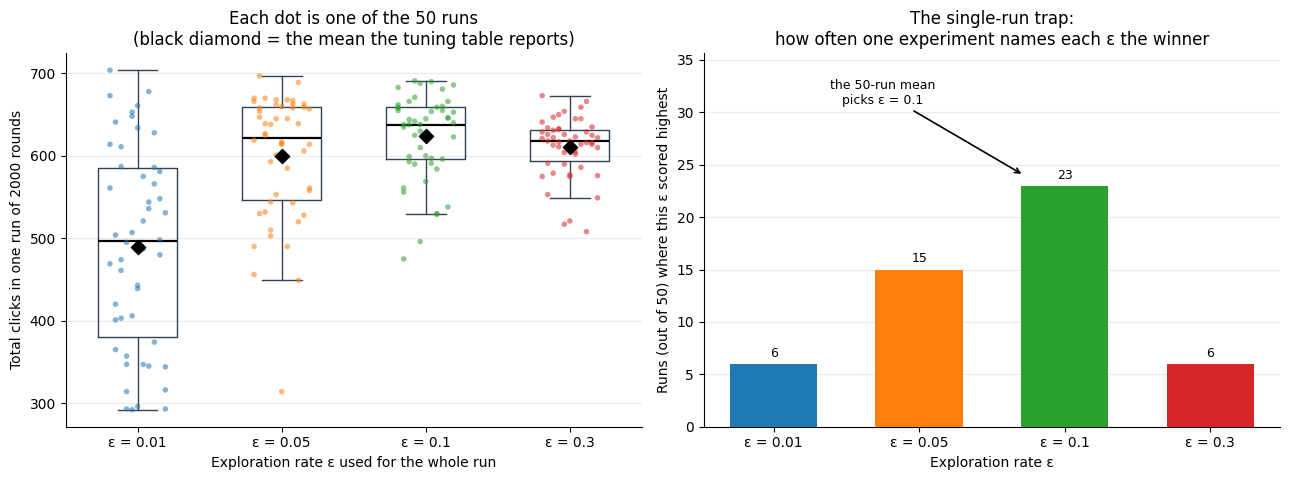

Overlap between the best and worst epsilon, measured on the 50 runs:
  ε = 0.01  mean  489.0   spread 292 … 704
  ε = 0.05  mean  599.6   spread 314 … 697
  ε = 0.1   mean  623.7   spread 475 … 691
  ε = 0.3   mean  610.8   spread 508 … 673

Single-run winners: ε=0.01: 6, ε=0.05: 15, ε=0.1: 23, ε=0.3: 6
The 50-run mean picks ε = 0.1; a single run agrees only 23/50 of the time.


In [4]:
# Closing figure: the tuning table's error bars, opened up.
# Left  — all 50 run totals per epsilon, not just their mean.
# Right — how often ONE run would have crowned each epsilon (the single-run trap).
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

eps_labels = [f"ε = {e}" for e in EPSILONS]
eps_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
x = np.arange(len(EPSILONS))          # four epsilon settings: categories, so bars/boxes, never a line

fig, (ax_spread, ax_wins) = plt.subplots(1, 2, figsize=(13, 4.9))

# ---------- Left: the whole distribution behind each error bar ----------
per_eps_totals = [results[e]["totals"] for e in EPSILONS]
bp = ax_spread.boxplot(per_eps_totals, positions=x, widths=0.55, showfliers=False,
                       medianprops=dict(color="black", lw=1.6),
                       boxprops=dict(color="#334155"), whiskerprops=dict(color="#334155"),
                       capprops=dict(color="#334155"))

# Every single run drawn as a dot. Offsets are a fixed repeating pattern, not random,
# so the picture is identical every time you run the notebook.
spread_offsets = ((np.arange(N_RUNS) % 11) - 5) / 26.0
for xi, (totals, color) in enumerate(zip(per_eps_totals, eps_colors)):
    ax_spread.scatter(xi + spread_offsets, totals, s=16, color=color, alpha=0.55,
                      edgecolor="none", zorder=3)
    ax_spread.scatter([xi], [totals.mean()], marker="D", s=52, color="black", zorder=4)

ax_spread.set_xticks(x)
ax_spread.set_xticklabels(eps_labels)
ax_spread.set_xlabel("Exploration rate ε used for the whole run")
ax_spread.set_ylabel(f"Total clicks in one run of {N_ROUNDS} rounds")
ax_spread.set_title(f"Each dot is one of the {N_RUNS} runs\n(black diamond = the mean the tuning table reports)")
ax_spread.spines[["top", "right"]].set_visible(False)
ax_spread.grid(axis="y", alpha=0.25)

# ---------- Right: who would have won if you had only looked at one run? ----------
win_counts = Counter(single_run_winners)
wins = [win_counts.get(e, 0) for e in EPSILONS]
bars = ax_wins.bar(x, wins, 0.6, color=eps_colors, zorder=3)
ax_wins.bar_label(bars, fmt="%d", padding=3, fontsize=9)

# Mark the value the honest 50-run average actually chose.
winner_idx = EPSILONS.index(best_eps)
ax_wins.annotate(f"the {N_RUNS}-run mean\npicks ε = {best_eps}",
                 xy=(winner_idx - 0.28, wins[winner_idx] + 1.0),
                 xytext=(winner_idx - 1.25, max(wins) * 1.34),
                 ha="center", fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="black", lw=1.2))
ax_wins.set_xticks(x)
ax_wins.set_xticklabels(eps_labels)
ax_wins.set_xlabel("Exploration rate ε")
ax_wins.set_ylabel(f"Runs (out of {N_RUNS}) where this ε scored highest")
ax_wins.set_title("The single-run trap:\nhow often one experiment names each ε the winner")
ax_wins.set_ylim(0, max(wins) * 1.55)
ax_wins.spines[["top", "right"]].set_visible(False)
ax_wins.grid(axis="y", alpha=0.25, zorder=0)

plt.tight_layout()
plt.show()

print(f"Overlap between the best and worst epsilon, measured on the {N_RUNS} runs:")
for eps in EPSILONS:
    t = results[eps]["totals"]
    print(f"  ε = {eps:<5} mean {t.mean():6.1f}   spread {t.min():.0f} … {t.max():.0f}")
print(f"\nSingle-run winners: " + ", ".join(f"ε={e}: {win_counts.get(e, 0)}" for e in EPSILONS))
print(f"The {N_RUNS}-run mean picks ε = {best_eps}; a single run agrees only "
      f"{win_counts.get(best_eps, 0)}/{N_RUNS} of the time.")


### 👁️ Read the figure

**Left — the error bars, opened up.** Each dot is one complete 2,000-round simulation; the box
is the middle half of the 50, and the black diamond is the mean the tuning table quotes.
- **ε = 0.01 is not just worse, it is a lottery**: its 50 runs run from **292 to 704 clicks**.
  Its best run beat every run of every other setting. With ε that small, whether the agent ever
  stumbles onto variant 2 decides the entire campaign.
- **ε = 0.3 is the tightest cloud (508 … 673)** and ε = 0.1 the highest mean (623.7). Their two
  clouds overlap almost completely.

**Right — the trap this lesson is about.** Counting the winner of each individual run:
**ε = 0.1 wins 23 of 50**, ε = 0.05 wins 15, and ε = 0.01 and ε = 0.3 win 6 each. So a
single experiment — the kind every earlier lesson in this unit ran — points at the
50-run answer **fewer than half the time**.

**How far the 50 runs actually take you.** Because the same 50 seeds are reused for every ε,
the settings can be compared run by run. Paired that way, ε = 0.1 beats ε = 0.3 by **12.9
clicks with a standard error of 7.6 (t ≈ 1.7)**.

**What it proves:** 50 runs is enough to say **ε = 0.01 is genuinely bad**, and it is *not*
enough to crown ε = 0.1 over ε = 0.3. "Best epsilon by mean total reward" is a headline that
needs its spread printed next to it — which is why the table above prints min … max, and why
the honest conclusion here is a shortlist, not a winner.

## ⚠️ Where this breaks

**The assumption that has to hold:** the parameter that wins on your measurement is winning for the
reason you think, and will keep winning.

- **Averaging fixes the noise, not the target.** 50 runs tell you which ε is best *on these arms, at
  this horizon*. Change the number of rounds and the ranking moves: a short horizon favours less
  exploration, a long one favours more. The tuned value is a property of the experiment, not of the
  algorithm.
- **Improving a metric is not evidence that your mechanism works.** Shao et al. ("Spurious Rewards:
  Rethinking Training Signals in RLVR", arXiv 2506.10947, 2025) obtained a **21.4 percentage point**
  gain on MATH-500 by training with *randomly assigned* rewards, against 29.1 with true ones — and the
  effect did not reproduce on other model families. A knob that moves your number may be moving it
  through a mechanism you have not identified. Ablate before you believe.
- **Tuning on the data you report on is cheating, quietly.** If you select ε by its score on these 50
  runs and then report that score, you have reported a maximum over four options, not an estimate.
  Hold out a fresh set of runs for the number you publish.
- **Offline replay needs logged action probabilities.** The Yahoo method works because the logging
  policy was random and its choices were recorded. If your production system logged only *which*
  action it took, unbiased offline comparison is not available to you at any price — and the time to
  fix that is before you need it.
- **Cheaper alternative:** rather than tuning ε at all, use a strategy with no exploration schedule:
  UCB's bonus and Thompson's posterior both shrink exploration automatically as evidence accumulates.
  On this notebook's own arms they beat every ε in the table above. Tuning ε is what you do when you
  are committed to ε-greedy for reasons of simplicity or auditability — which is a legitimate reason,
  but it should be a decision, not a default.


## Closing Takeaway

**Teaching takeaway:** Parameter tuning changes how aggressively or cautiously an agent explores, which can strongly affect speed and final performance.

**If students remember one idea:** A strategy is only half the story. Its parameter values determine how it behaves in the real run.

**Quick check before moving on:**
- Can you explain why a strong method can still perform poorly with weak parameter choices?
- Can you describe which signals you would inspect while tuning exploration?

**Bridge to the next step:** This closes Unit 4 and prepares students to apply RL ideas in larger, more realistic domains.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

The discipline this lesson enforces — many independent runs per setting, compare means with their
spread, never rank on one run — is now the field's minimum standard, and two recent results show why it
has to be. Shao et al. trained Qwen2.5-Math-7B with *randomly assigned* rewards and still gained 21.4
percentage points on MATH-500, against a 29.1-point gain from ground-truth rewards; the spurious rewards
that worked on Qwen models often produced no gain on other families such as Llama3 or OLMo2, so a knob
that moves your number is not evidence that the mechanism you named is what moved it (arXiv:2506.10947,
2025). The same conclusion arrived from agent evaluation: on the Thinkingbox business-workflow benchmark
the strongest system scores 65.36% on a single attempt and 25.25% when the same task must succeed on
twenty (Li et al., arXiv:2608.19741, 2026). What practitioners do now follows directly — report
distributions rather than best runs, report repeated-success rates rather than one pass, and hold out
fresh runs for the number that goes in the report. None of that replaces the ε sweep below: the sweep is
where you can watch the single-run trap actually happen, count it (27 of 50 runs would crown a different
ε), and fix it with one extra loop — which is the habit the official plan is asking you to carry into
every RL result you report.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=9 | term=True | trunc=False


objc[59757]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1148e8138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114ee49c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[59757]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1148e8188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114ee4a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[59757]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1148e7c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114ee4a68). T

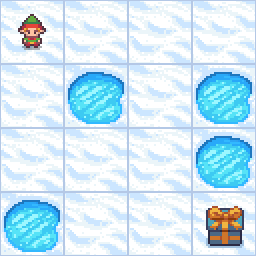

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Find the shared Course 09 helper (course09_step_viz.py) from ANY folder, and on Google Colab.
# WHAT: look for the helper up the folder chain, then inside a "Course 09" folder on that chain,
#       and only then download it; finally put its folder on Python's import path.
# WHY:  searching only the PARENTS of the working directory breaks the moment you open this
#       notebook from the repository root - there the helper sits in a child folder, not a
#       parent - and on Colab there is no repository at all. This does not care where you
#       started the kernel from.
_HELPER_C9 = "course09_step_viz.py"
_chain_c9 = [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
_course09 = next((d for d in _chain_c9 if (d / _HELPER_C9).exists()), None)
if _course09 is None:                      # opened from the repo root, or from another course
    _course09 = next((d / "Course 09" for d in _chain_c9
                      if (d / "Course 09" / _HELPER_C9).exists()), None)
if _course09 is None:                      # Google Colab, or a stray copy of this notebook
    import urllib.request
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
            "Course%2009/" + _HELPER_C9, _HELPER_C9)
    except Exception as _e:
        raise FileNotFoundError(
            f"Could not find {_HELPER_C9} from this folder, and could not download it either. "
            "Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet and "
            f"re-run this cell. (underlying error: {_e})") from None
    _course09 = pathlib.Path.cwd()

# Put that folder on Python's import path so the helper imports from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
